# フェーズ6.5：実データ予測（A系統・プール方式）

CSPM 購買データを **86店舗プール**（連続日次60日以上）で学習し、
**購買来店数（receipts）→ 客単価 → 純売上（net_sales）** を予測する。

- 特徴量：カレンダー（曜日・祝日・給料日等）＋ **店舗ID（カテゴリ）** ＋ ラグ・移動平均
- 天候・SNS・販促：当面なし（フェーズ6方針どおり）
- 検証：`test_end` で終了日を指定し、そこから遡って14日間を未来データとして評価（デフォルトは **12月前半**）

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

sys.path.append(str(Path.cwd() / "src"))
from real_visit_forecast import (
    FEATURES,
    SPEND_FEATURES,
    compare_validation_periods,
    evaluate,
    load_pooled_panel,
    predict_baselines,
    run_evaluation,
    train_models_pooled,
)

pd.set_option("display.width", 120)
TEST_DAYS = 14
MIN_DAYS = 60
# 検証終了日（None=データ最終日）。通常期の 12/15 をデフォルトに設定
TEST_END = "2024-12-15"

## 1. データ読込（プール）

連続日次が `MIN_DAYS` 以上ある店舗をプールする。現データでは **86店×91日（2024-10〜12）** のパネルになる。

In [2]:
pooled, dense_shops = load_pooled_panel(min_days=MIN_DAYS)
print(f"プール: {len(pooled):,} 行 / {len(dense_shops)} 店舗")
print(f"期間: {pooled['date'].min().date()} 〜 {pooled['date'].max().date()}")
print(f"検証: {TEST_DAYS} 日間（終了日={TEST_END or 'データ最終日'}）")
pooled.head()

プール: 7,749 行 / 86 店舗
期間: 2024-10-01 〜 2024-12-30
検証: 14 日間（終了日=2024-12-15）


,shop_id,date,receipts,members,gross_sales,discount,returns,return_amount,net_sales,avg_spend
0,005497,2024-10-01,83,69,639656,4081,1.0,3522.0,636134.0,7664.3
1,005497,2024-10-02,87,80,643745,18112,0.0,-0.0,643745.0,7399.4
2,005497,2024-10-03,67,61,415665,5477,1.0,1991.0,413674.0,6174.2
3,005497,2024-10-04,78,64,490114,9459,1.0,35334.0,454780.0,5830.5
4,005497,2024-10-05,78,64,356441,472,1.0,435.0,356006.0,4564.2


## 2. 検証期間の比較

検証終了日（`test_end`）を変え、14日間の精度を比較する。
**12月後半（年末）** だけが極端に悪く、通常期（10〜12月前半）は MAPE 8〜15% 程度になる。

,検証設定,検証期間,学習終了,来店MAPE(%),来店繁忙日MAPE(%),売上MAPE(%),検証前半MAPE(%),検証後半MAPE(%)
0,10月後半,2024-10-18〜2024-10-31,2024-10-17,15.1,12.3,27.1,10.8,9.1
1,11月後半,2024-11-17〜2024-11-30,2024-11-16,8.3,5.7,26.4,2.3,1.8
2,12月前半,2024-12-02〜2024-12-15,2024-12-01,7.8,4.9,19.9,2.4,1.2
3,12月後半(年末),2024-12-17〜2024-12-30,2024-12-16,29.2,7.7,42.4,3.5,46.9


/var/folders/mv/pf3ds0354lg1197v9l57snzw0000gn/T/ipykernel_50433/2529701415.py:21: UserWarning: Glyph 26376 (\N{CJK UNIFIED IDEOGRAPH-6708}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mv/pf3ds0354lg1197v9l57snzw0000gn/T/ipykernel_50433/2529701415.py:21: UserWarning: Glyph 24460 (\N{CJK UNIFIED IDEOGRAPH-5F8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mv/pf3ds0354lg1197v9l57snzw0000gn/T/ipykernel_50433/2529701415.py:21: UserWarning: Glyph 21322 (\N{CJK UNIFIED IDEOGRAPH-534A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mv/pf3ds0354lg1197v9l57snzw0000gn/T/ipykernel_50433/2529701415.py:21: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mv/pf3ds0354lg1197v9l57snzw0000gn/T/ipykernel_50433/2529701415.py:21: UserWarning: Glyph 24180 (\N{CJK UNIFIED IDEOGRAPH-5E74}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/mv/pf3d

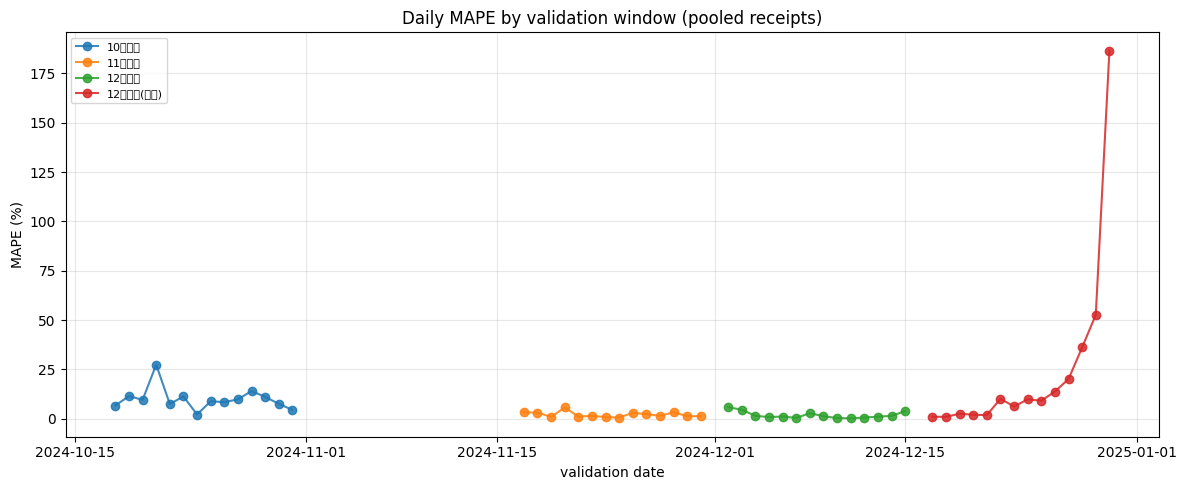

In [3]:
VALIDATION_SCENARIOS = [
    {"name": "10月後半", "test_end": "2024-10-31"},
    {"name": "11月後半", "test_end": "2024-11-30"},
    {"name": "12月前半", "test_end": "2024-12-15"},
    {"name": "12月後半(年末)", "test_end": "2024-12-30"},
]

summary, daily_errors = compare_validation_periods(
    pooled, VALIDATION_SCENARIOS, test_days=TEST_DAYS
)
display(summary)

fig, ax = plt.subplots(figsize=(12, 5))
for name, daily in daily_errors.items():
    ax.plot(daily["date"], daily["ape"], "o-", label=name, alpha=0.85)
ax.set_title("Daily MAPE by validation window (pooled receipts)")
ax.set_ylabel("MAPE (%)")
ax.set_xlabel("validation date")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 学習・精度評価（デフォルト検証期間）

上記の比較を踏まえ、通常期である **12月前半（12/2〜12/15）** をデフォルトの検証期間として詳細を見る。
`TEST_END` を変更すれば、別の期間でも同様に評価できる。

In [4]:
models = train_models_pooled(pooled, test_days=TEST_DAYS, test_end=TEST_END)
visit_results, sales_results, test_df = run_evaluation(models)

print("学習終了日:", models.train_end.date())
print("検証期間:", models.test_start.date(), "〜", models.test_end.date())
print("\n=== 購買来店数（receipts）===")
display(visit_results.round(1))
print("\n=== 純売上（net_sales）===")
display(sales_results.round(1))

学習終了日: 2024-12-01
検証期間: 2024-12-02 〜 2024-12-15

=== 購買来店数（receipts）===


,モデル,MAE,RMSE,MAPE(%),繁忙日MAPE(%)
0,勾配ブースティング,17.0,22.5,7.8,4.9
1,ベースラインA(7日前),20.7,26.9,9.2,6.2
2,ベースラインB(7日移動平均),42.4,60.9,20.6,10.5
3,ベースラインC(店舗×曜日平均),22.1,29.0,9.1,7.3



=== 純売上（net_sales）===


,モデル,MAE,RMSE,MAPE(%),繁忙日MAPE(%)
0,来店×客単価,274019.9,411768.6,19.9,12.8
1,ベースライン(7日前×客単価),290623.0,428466.0,22.8,13.3
2,ベースライン(曜日平均×客単価),283710.1,429759.5,20.5,14.1


## 4. 予測 vs 実績（プール合計・日次）

全店舗を日次で合計し、検証期間の推移を見る。

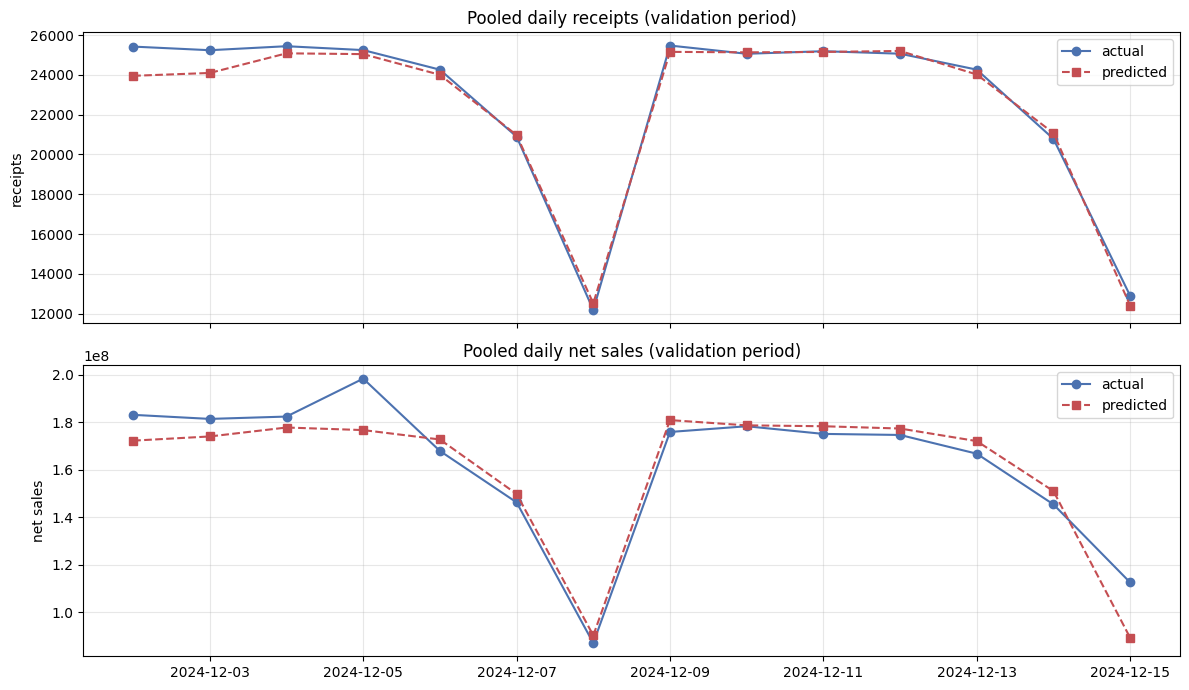

In [5]:
daily = test_df.groupby("date").agg(
    receipts=("receipts", "sum"),
    pred_receipts=("pred_receipts", "sum"),
    net_sales=("net_sales", "sum"),
    pred_net_sales=("pred_net_sales", "sum"),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(daily["date"], daily["receipts"], "o-", label="actual", color="#4C72B0")
axes[0].plot(daily["date"], daily["pred_receipts"], "s--", label="predicted", color="#C44E52")
axes[0].set_title("Pooled daily receipts (validation period)")
axes[0].set_ylabel("receipts")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(daily["date"], daily["net_sales"], "o-", label="actual", color="#4C72B0")
axes[1].plot(daily["date"], daily["pred_net_sales"], "s--", label="predicted", color="#C44E52")
axes[1].set_title("Pooled daily net sales (validation period)")
axes[1].set_ylabel("net sales")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. 店舗別の予測例

プールモデルでも、店舗ごとの予測は `shop_id_code` により店舗特性を反映する。

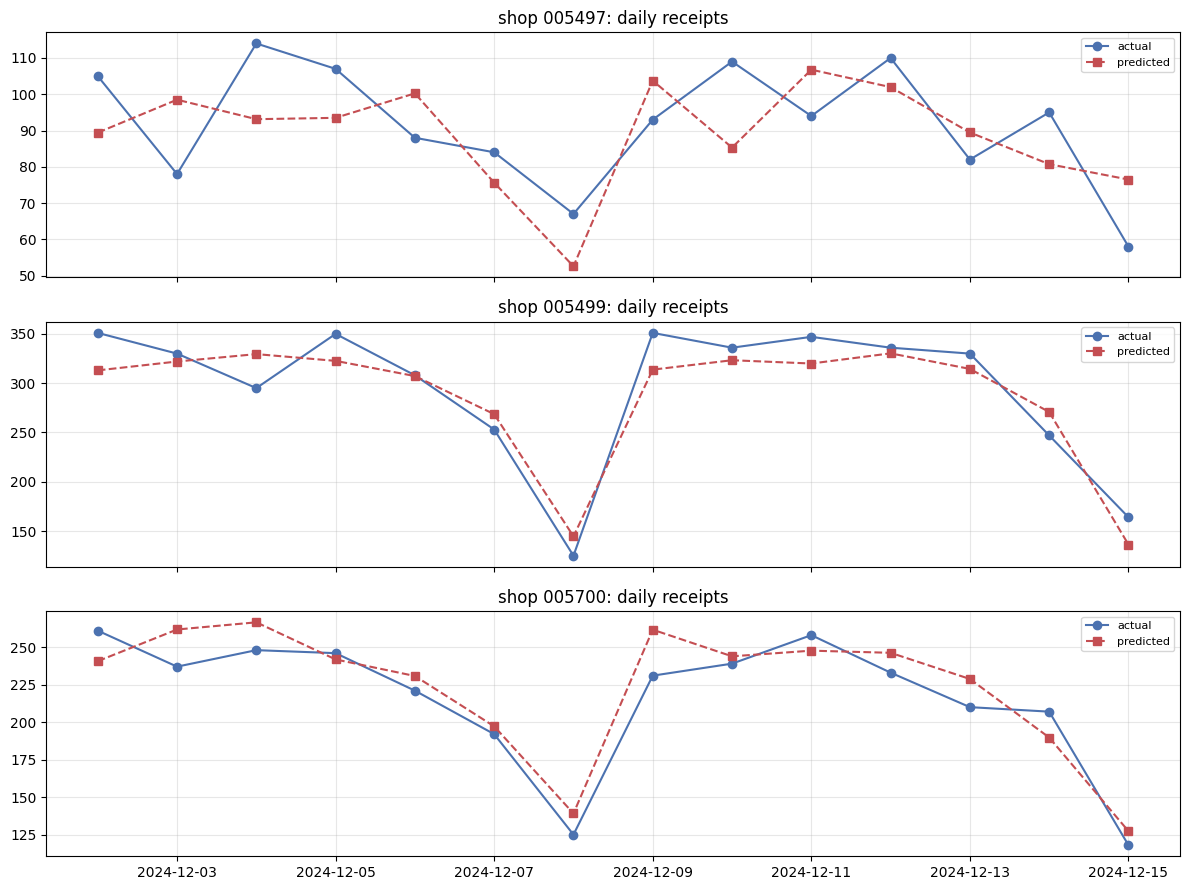

In [6]:
sample_shops = test_df["shop_id"].drop_duplicates().head(3).tolist()
fig, axes = plt.subplots(len(sample_shops), 1, figsize=(12, 3 * len(sample_shops)), sharex=True)
if len(sample_shops) == 1:
    axes = [axes]

for ax, shop_id in zip(axes, sample_shops):
    d = test_df[test_df["shop_id"] == shop_id].sort_values("date")
    ax.plot(d["date"], d["receipts"], "o-", label="actual", color="#4C72B0")
    ax.plot(d["date"], d["pred_receipts"], "s--", label="predicted", color="#C44E52")
    ax.set_title(f"shop {shop_id}: daily receipts")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 特徴量重要度

来店予測モデルで、どの特徴が効いているかを確認する。

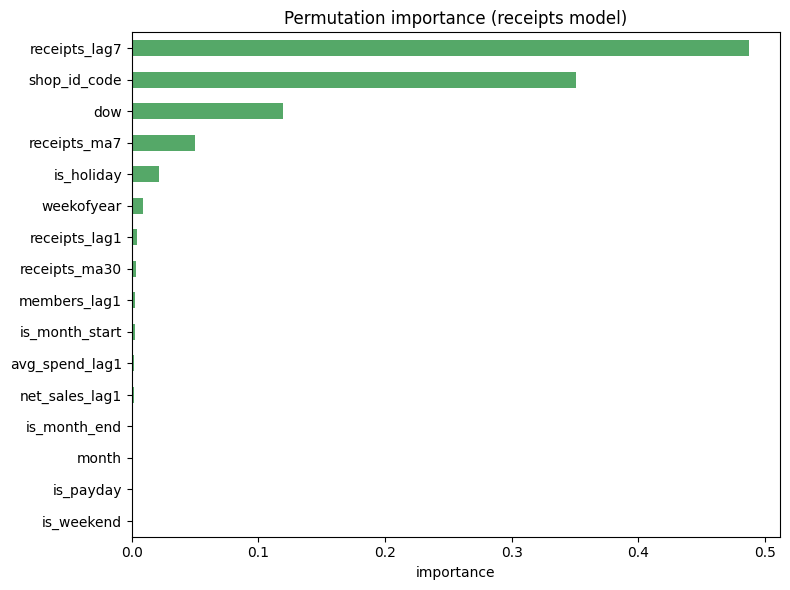

receipts_lag7    0.487653
shop_id_code     0.350679
dow              0.119715
receipts_ma7     0.050138
is_holiday       0.021157
weekofyear       0.009178
receipts_lag1    0.003963
receipts_ma30    0.002977
dtype: float64

In [7]:
train = models.df_feat[models.df_feat["date"] < models.test_start]
X_train = train[FEATURES]
y_train = train["receipts"]
perm = permutation_importance(
    models.visit_model, X_train, y_train,
    n_repeats=5, random_state=42, n_jobs=-1,
)
imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
imp.plot(kind="barh", ax=ax, color="#55A868")
ax.set_title("Permutation importance (receipts model)")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()
imp.sort_values(ascending=False).head(8)

## 7. 純売上の直接予測（比較）

「来店×客単価」分解に加え、純売上を直接予測した場合と比較する。

In [8]:
df_feat = models.df_feat
train = df_feat[df_feat["date"] < models.test_start]
test = test_df.copy()

sales_features = FEATURES
cat_idx = [sales_features.index("shop_id_code")]
sales_model = HistGradientBoostingRegressor(
    max_iter=500, learning_rate=0.05, max_depth=6, l2_regularization=1.0,
    early_stopping=True, validation_fraction=0.15, random_state=42,
    categorical_features=cat_idx,
)
sales_model.fit(train[sales_features], train["net_sales"])
pred_sales_direct = sales_model.predict(test[sales_features])

bases = predict_baselines(train, test)
base_sales_dow = bases["dow"] * bases["spend_dow"]

direct_result = pd.DataFrame([
    evaluate("来店×客単価", test["net_sales"].values, test["pred_net_sales"].values),
    evaluate("純売上(直接予測)", test["net_sales"].values, pred_sales_direct),
    evaluate("ベースライン(曜日平均×客単価)", test["net_sales"].values, base_sales_dow),
])
display(direct_result.round(1))

,モデル,MAE,RMSE,MAPE(%),繁忙日MAPE(%)
0,来店×客単価,274019.9,411768.6,19.9,12.8
1,純売上(直接予測),270059.5,409354.4,19.2,13.2
2,ベースライン(曜日平均×客単価),283710.1,429759.5,20.5,14.1


## 8. 疎な店舗（連続日次でない101店舗）の活用

これまでは **連続日次60日以上の86店舗** だけを使っていた。残り101店舗は、
最初の数日だけ連続しその後は月1〜2回程度しかレコードがない「疎な」データで、
「7日前」「直近7日平均」といったカレンダー基準のラグが機能しない。

これらを活かす2つの方式を、**同じ検証期間（12月前半）** で従来方式と比較する。

- **B案：カレンダーのみモデル** — ラグを使わず、曜日・月・祝日・給料日＋店舗IDのみで学習。ラグが不要なので全187店舗・全行を使える。
- **A案：直近実績ラグ＋空白日数** — 「Nカレンダー日前」ではなく「直近の観測レコード」をラグにし、前回からの空白日数（`gap_days`）を特徴量として明示する。187店をプールできる。

In [9]:
from real_visit_forecast import load_full_panel, compare_coverage_strategies

df_full = load_full_panel()
print(f"全体パネル: {len(df_full):,} 行 / {df_full['shop_id'].nunique()} 店舗")

coverage_summary, coverage_frames = compare_coverage_strategies(
    df_full, test_days=TEST_DAYS, test_end=TEST_END
)
display(coverage_summary)

全体パネル: 9,944 行 / 187 店舗


,方式,対象店舗数,評価行数,MAPE(%),繁忙日MAPE(%)
0,従来:密店舗のみ(min_days=60),86,1200,7.8,4.9
1,B案:カレンダーのみ(全187店),187,1221,8.7,4.9
2,A案:直近実績ラグ+空白日数(全187店),187,1221,9.8,4.8


### 学習に使える行数・店舗数の比較

精度だけでなく、「どれだけのデータを学習に使えているか」も確認する。

In [10]:
from real_visit_forecast import build_features_full, build_features_pooled, FEATURES_REQUIRED

dense_train_rows = len(build_features_pooled(pooled).dropna(subset=FEATURES_REQUIRED))
full_train_rows = len(build_features_full(df_full).dropna(subset=["receipts_lag1_asof"]))

print(f"従来（密店舗86店）で学習に使える行数: {dense_train_rows:,}")
print(f"A案（全187店・asof）で学習に使える行数: {full_train_rows:,}")
print(f"増加: +{full_train_rows - dense_train_rows:,} 行 "
      f"({(full_train_rows/dense_train_rows - 1)*100:.0f}%)")

従来（密店舗86店）で学習に使える行数: 7,147
A案（全187店・asof）で学習に使える行数: 9,757
増加: +2,610 行 (37%)


### A案の特徴量重要度（gap_days は効いているか）

「空白日数」を明示的にモデルに教えることで、疎なラグの信頼度をどの程度学習できているかを確認する。

/var/folders/mv/pf3ds0354lg1197v9l57snzw0000gn/T/ipykernel_50433/2580935857.py:16: UserWarning: Glyph 26696 (\N{CJK UNIFIED IDEOGRAPH-6848}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/dai-ku.k/青梅DX_クレアンスメアード/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26696 (\N{CJK UNIFIED IDEOGRAPH-6848}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


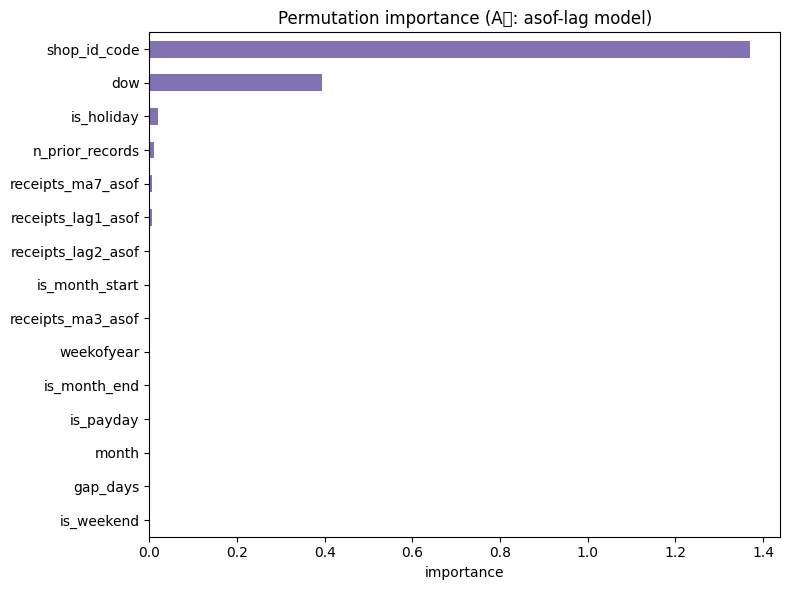

shop_id_code          1.370073
dow                   0.394938
is_holiday            0.018600
n_prior_records       0.011677
receipts_ma7_asof     0.005551
receipts_lag1_asof    0.004920
receipts_lag2_asof    0.002332
is_month_start        0.001885
receipts_ma3_asof     0.001083
weekofyear            0.000764
is_month_end          0.000531
is_payday             0.000198
month                 0.000124
gap_days              0.000020
is_weekend            0.000000
dtype: float64

In [11]:
from real_visit_forecast import train_asof_model, ASOF_FEATURES

asof_result = train_asof_model(df_full, test_days=TEST_DAYS, test_end=TEST_END)
asof_train = asof_result.df_feat[asof_result.df_feat["date"] < asof_result.test_start]

perm = permutation_importance(
    asof_result.model, asof_train[ASOF_FEATURES], asof_train["receipts"],
    n_repeats=5, random_state=42, n_jobs=1,
)
imp_asof = pd.Series(perm.importances_mean, index=ASOF_FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
imp_asof.plot(kind="barh", ax=ax, color="#8172B3")
ax.set_title("Permutation importance (A案: asof-lag model)")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()
imp_asof.sort_values(ascending=False)

## 9. まとめ

### 検証期間を変えた結果
- **10月後半 / 11月後半 / 12月前半**：来店 MAPE **8〜15%**、日次推移も安定
- **12月後半（年末）**：来店 MAPE **29%**、12/28〜30 で急落を捉えきれず後半 MAPE **47%**

→ 以前見えていた「後半ほど外れる」現象は、**年末の特殊期間**が主因。通常期ではモデルはベースラインを上回る精度。

### 疎な101店舗の活用（A案・B案）
- **B案（カレンダーのみ）**：MAPE 8.7%（従来7.8%とほぼ同等）で全187店舗を学習に使える
- **A案（直近実績ラグ＋空白日数）**：MAPE 9.8%（やや劣化）だが学習行数が7,147→9,757行（**+37%**）に増加
- 特徴量重要度は `shop_id_code` と `dow` が支配的で、`gap_days` 自体の寄与は小さい（店舗×曜日の傾向で大半を説明できてしまうため）
- → **精度をほぼ落とさず店舗網羅性を優先するならB案、疎店舗のラグ情報も多少活かしたいならA案**。どちらも「連続日次が必須」という制約からは脱却できる

### その他
- 売上は客単価のばらつきが大きく、分解方式はベースラインと同程度
- 天候・販促・年末フラグの追加で改善余地あり

### 次のステップ
- **フェーズ6.6**：B系統（通行人カウント単店）の予測
- **実データ版フェーズ5**：予測結果を `llm_advisor.py` で解釈・施策提案